**LOADING PACGAGES**

In [1]:
import pandas as pd
from google.colab import drive
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np


**LOADING DATASETS**

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#importing datasets
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSPL/Hotel-A-train_cleaned.CSV")
df_val = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSPL/Hotel-A-validation_cleaned.CSV")

Processing

In [4]:
df['Reservation_Status'] = df['Reservation_Status'].replace('Check-out', 'Check-Out')

In [5]:
df['Reservation_Status'] = df['Reservation_Status'].replace('Check-In', 'Check-Out')
df['Reservation_Status'] = df['Reservation_Status'].str.lower()

df_val['Reservation_Status'] = df_val['Reservation_Status'].replace('Check-In', 'Check-Out')
df_val['Reservation_Status'] = df_val['Reservation_Status'].str.lower()

In [6]:
# Creating a new variable and deleting the previous variables used to make it
df['Total_Guests'] = (df['Adults'] + df['Children'] + df['Babies'])

# Creating a new variable and deleting the previous variables used to make it
df_val['Total_Guests'] = (df_val['Adults'] + df_val['Children'] + df_val['Babies'])

In [7]:
# Extract Seasonality (Month of check-in)
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df_val['Expected_checkin'] = pd.to_datetime(df_val['Expected_checkin'])

df['Checkin_Month'] = df['Expected_checkin'].dt.month
df_val['Checkin_Month'] = df_val['Expected_checkin'].dt.month

In [8]:
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


****

In [9]:
# selecting the feature columns
training_feature_cols = df.drop(
['Reservation-id','Expected_checkin','Expected_checkout','Adults', 'Children', 'Babies'],
axis=1
)
testing_feature_cols = df_val.drop(
['Reservation-id','Expected_checkin','Expected_checkout','Adults', 'Children', 'Babies'],
axis=1
)

In [10]:
#split dataset in features and target variable
dependent_variable='Reservation_Status'

# Features for training data
X_train = training_feature_cols.drop(columns=[dependent_variable])
y_train = df[dependent_variable]# Target variable

# Features for testing data
X_val = testing_feature_cols.drop(columns=[dependent_variable])
y_val = df_val[dependent_variable] # Target variable

In [11]:
X_val.head(1)

,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Booking_date,Meal_Type,Visted_Previously,...,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion,Discount_Rate,Room_Rate,Lead_Time,Length_of_Stay,Total_Guests,Checkin_Month
0,M,56,caucasian,Grad,<25K,West,Resort,2016-02-18,HB,No,...,No Deposit,Agent,No,Yes,15,192,195,2,4,8


In [12]:
#getting dummy variables
X_train = pd.get_dummies(X_train)
X_val= pd.get_dummies(X_val)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

In [13]:
# Encode target labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val= le.transform(y_val)

In [14]:
# scaling data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1_train = scaler.fit_transform(X_train)
X1_val = scaler.transform(X_val)


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X1_train, y_train)

In [17]:
#from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000)

logreg.fit(X_resampled, y_resampled)

y_pred = logreg.predict(X1_val)

In [18]:
y_pred

array([0, 0, 2, ..., 1, 2, 1])

In [19]:
Comparison_df = pd.DataFrame({'Actual Diabetic Diagnoses' : y_val,  'Predicted' : y_pred})
Comparison_df.to_csv(r'/content/Diagnoses_Comparison_df.csv', index=True)
Comparison_df


,Actual Diabetic Diagnoses,Predicted
0,2,0
1,0,0
2,0,2
3,1,1
4,1,0
...,...,...
2728,1,1
2729,0,0
2730,2,1
2731,1,2


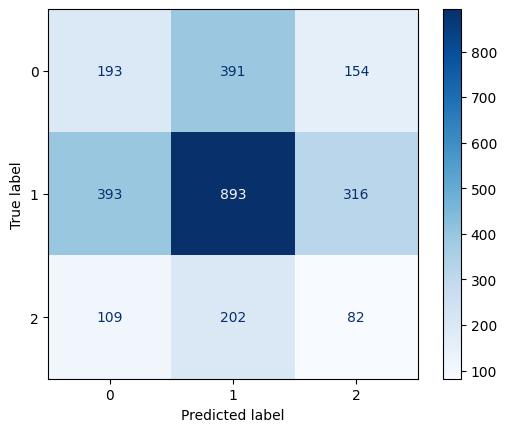

In [20]:
# To plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_val, y_pred, labels=logreg.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
disp.plot(cmap='Blues')

**RANDOM FORREST CLASSIFIER**

In [16]:
!pip install boruta

borutaPy was installed to select the best features by feature scaling




In [21]:

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.linear_model import LogisticRegression

# Initialize Random Forest
rf_base = RandomForestClassifier(n_jobs=-1, max_depth= 10,min_samples_split= 5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(rf_base, n_estimators='auto', verbose=2, random_state=42, max_iter=50)

# Fitting Boruta
print("Starting Boruta feature selection. This may take a few minutes...")
boruta_selector.fit(X_resampled, y_resampled)

# Transform the datasets to keep only the features Boruta confirmed are useful
X_resampled_boruta = boruta_selector.transform(X_resampled)
X1_val_boruta = boruta_selector.transform(X1_val)

# Train your final Logistic Regression model
logreg_final = LogisticRegression(max_iter=1000)
logreg_final.fit(X_resampled_boruta, y_resampled)

# Predict and evaluate
y_pred_ = logreg_final.predict(X1_val_boruta)

# Print the results
print(f"Original features: {X_resampled.shape[1]}")
print(f"Selected features: {X_resampled_boruta.shape[1]}")

Starting Boruta feature selection. This may take a few minutes...
Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	1172
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	0
Tentative: 	47
Rejected: 	1125
Iteration: 	9 / 50
Confirmed: 	47
Tentative: 	0
Rejected: 	1125


BorutaPy finished running.

Iteration: 	10 / 50
Confirmed: 	47
Tentative: 	0
Rejected: 	1125
Original features: 1172
Selected features: 47


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_))


              precision    recall  f1-score   support

           0       0.29      0.37      0.32       738
           1       0.61      0.51      0.55      1602
           2       0.14      0.16      0.15       393

    accuracy                           0.42      2733
   macro avg       0.34      0.34      0.34      2733
weighted avg       0.45      0.42      0.43      2733



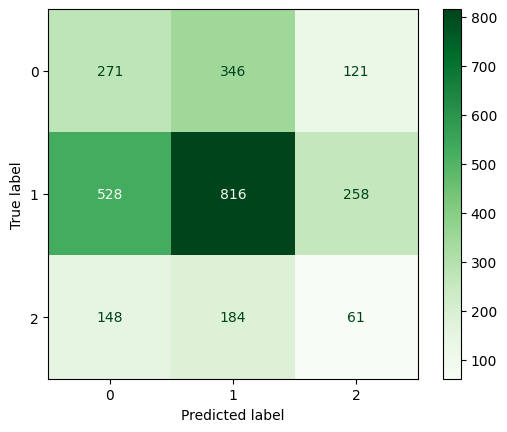

In [23]:
# To plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_val, y_pred_, labels=logreg_final.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg_final.classes_)
disp.plot(cmap='Greens')


In [24]:
logModel = LogisticRegression()

In [25]:
param_grid = [
    {'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'C' : [0.01,0.1,1,10],
    'solver' : ['lbfgs','newton-cg','liblinear','sag','saga'],
    'max_iter' : [1000]
    }
]

In [26]:
from sklearn.model_selection import GridSearchCV


In [27]:
clf = GridSearchCV(logModel,
                   param_grid = param_grid,
                   cv = 3,
                   verbose=True,
                   n_jobs=-1)

results after running the below codes are unknown due to the hightime consumption

In [ ]:
best_clf = clf.fit(X_resampled, y_resampled)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


In [ ]:
y_pred_clf = clf.predict(X1_val)

In [ ]:
# To plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_val, y_pred_clf, labels=clf.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=clf.classes_)
disp.plot()